# 04 — Reinforcement Learning Enzyme Combination Optimization

This notebook demonstrates the reinforcement learning component of HERALD —
the core innovation that distinguishes this pipeline from a standard computational
screening tool.

## What This Notebook Does

Rather than evaluating all enzyme combinations exhaustively as in notebook 03,
this notebook trains an epsilon-greedy agent to *learn* which enzyme combinations
produce the highest AMP probability peptides through iterative trial and error.
The agent starts with no knowledge and improves its recommendations over 100
episodes of interaction with the HERALD environment.

## Why Reinforcement Learning

Exhaustive screening works when the action space is small — 4 combinations is
manageable. But as HERALD expands to include more enzymes, sequential combinations,
and varying hydrolysis conditions, the search space grows exponentially. An RL
agent scales naturally to this complexity by learning to focus on promising
regions of the search space rather than testing everything.

This approach is directly analogous to reinforcement learning from verifiable
rewards (RLVR) — the reward signal (ESM-2 AMP probability) is a verifiable,
ground-truth-adjacent score rather than human preference. When wet lab MIC
values become available, they will replace or supplement the computational
reward signal, closing the experimental loop described in Aim 3.

## What You Will See

1. The agent starts with no knowledge and explores randomly
2. As epsilon decays, the agent shifts from exploration to exploitation
3. The learning curve shows total reward increasing over episodes as the
   agent converges on the best enzyme combination
4. The final recommendation identifies the optimal enzyme combination
   and top AMP candidates for wet lab validation

## Connection to the Broader HERALD Pipeline
Notebook 01 — Digestion exploration (single protein, single enzyme)

Notebook 02 — Rule-based screening (all proteins × all enzymes)

Notebook 03 — ML screening (ESM-2 classifier replaces heuristics)

Notebook 04 — RL optimization (agent learns optimal enzyme combination) ← you are here

The output of this notebook (the recommended enzyme combination and top
candidate peptides) feeds directly into Aim 2 wet lab validation. Experimental
MIC results will then be used in Aim 3 to recalibrate the reward signal and
run a second iteration of the RL loop.

In [23]:
import sys
import os
import joblib
import esm
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from herald.proteins import protein_sequence
from herald.databases import build_amp_database
from herald.predictor import prepare_dataset, compute_esm2_embeddings, train_classifier, predict_amp
from herald.agent import EpsilonGreedyAgent
from herald.environment import HERALDEnvironment
from herald.training import train
from herald.digestion import digest_sequential


## Load ESM-2 Model and AMP Classifier

This section loads the two components required for ML-based AMP scoring:

ESM-2 is a protein language model developed by Meta and trained on 250 million protein sequences. It converts each peptide sequence into a 320-dimensional embedding vector that captures biological properties such as charge distribution, hydrophobicity, and structural context. ESM-2 is used here as a fixed feature extractor — its weights are not updated during training.

The AMP classifier is a logistic regression model trained on top of ESM-2 embeddings using 17,897 validated antimicrobial peptides from the APD6 and DBAASP databases as positive examples, and 18,000 randomly generated peptide sequences as negative examples. The classifier achieved 97% accuracy and a ROC-AUC of 0.996 on the held-out test set.

If a cached classifier is found in data/processed/amp_classifier.pkl, it is loaded directly to avoid retraining. Otherwise, the full training pipeline is run and the classifier is saved for future use.

Both the ESM-2 model and classifier are loaded once here and passed through the screening pipeline — loading them per peptide would be prohibitively slow.

In [14]:
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
clf_path = os.path.join(PROCESSED_DIR, "amp_classifier.pkl")

if os.path.exists(clf_path):
    clf = joblib.load(clf_path)
    print("Loaded classifier from cache.")
else:
    amp_df = build_amp_database()
    X_train, X_test, y_train, y_test = prepare_dataset(amp_df, n_samples=18000)
    X_train_emb = compute_esm2_embeddings(X_train.tolist(), model, alphabet)
    clf = train_classifier(X_train_emb, y_train)
    print("Trained and saved new classifier.")

Loaded classifier from cache.


## Initialize Environment and Agent

### Target Protein — Lactoferrin

Lactoferrin was selected as the target protein for RL optimization based on
the results of notebooks 02 and 03, where it consistently ranked first across
both rule-based and ML-based screening. Trypsin and chymotrypsin digestion of
lactoferrin produced the highest number of predicted AMP candidates and the
highest individual AMP probabilities of all protein-enzyme combinations tested.

Lactoferrin is also biologically motivated — it is a naturally antimicrobial
whey protein with well-documented roles in innate immunity. Its hydrolysis
products have been reported in the literature as potent AMPs, providing
external validation that the pipeline is identifying real biological signals.

### The Environment

The HERALDEnvironment wraps the HERALD digestion and scoring pipeline as a
standard RL environment. At each step it accepts an enzyme combination index,
simulates sequential digestion of lactoferrin, scores the resulting peptides
using the ESM-2 AMP classifier, and returns a reward combining average and
maximum AMP probability across all peptides produced.

The action space contains four enzyme combinations:
- Single enzyme: trypsin, chymotrypsin
- Sequential: trypsin → chymotrypsin, chymotrypsin → trypsin

### The Agent

The EpsilonGreedyAgent is initialized with no knowledge of which enzyme
combinations are best — all action values start at zero. Over 100 episodes
it will explore the action space, accumulate reward estimates for each
combination, and converge on the combination that consistently produces
the highest AMP probability peptides.

Epsilon starts at 1.0 (fully random exploration) and decays toward 0.1
(mostly exploitation) as the agent accumulates experience. By the end of
training the agent will spend 90% of its steps exploiting the best known
combination and 10% continuing to explore.

In [15]:
env = HERALDEnvironment(
    protein_name="lactoferrin",
    protein_sequence=sequence,
    model=model,
    alphabet=alphabet,
    clf=clf,
)

agent = EpsilonGreedyAgent(
    n_actions=len(env.action_space),
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.995,
)

## Run Reinforcement Learning Training

This section runs the epsilon-greedy agent through 100 episodes of interaction
with the HERALD environment to learn the optimal enzyme combination for
lactoferrin hydrolysis.

### What Happens During Training

Each episode proceeds as follows:

1. The environment resets — tried combinations and reward history are cleared
2. The agent selects an action using epsilon-greedy exploration
3. The environment simulates digestion with the selected enzyme combination
4. ESM-2 embeddings and AMP probability scores are computed for all peptides
5. A reward is calculated as 0.4 × avg_probability + 0.6 × max_probability
6. The agent updates its value estimate for that action using a running average
7. Steps 2-6 repeat for max_steps=12 steps per episode
8. The episode total reward is recorded and a new episode begins

### What to Watch For

Progress is printed every 10 episodes showing total reward and current epsilon.
A rising total reward over episodes indicates the agent is successfully learning
to prefer higher-yielding enzyme combinations. Epsilon decreasing from 1.0
toward 0.1 shows the agent shifting from exploration to exploitation.

### Computational Note

Each step requires ESM-2 embedding and AMP probability scoring for all peptides
produced by the selected enzyme combination. On Apple Silicon MPS this takes
approximately 2-5 seconds per step — expect training to take 20-40 minutes
for 100 episodes. The classifier and ESM-2 model are already loaded so no
additional setup is required.

In [16]:
results = train(env, agent, n_episodes=100)

Episode 10/100 | Total reward: 10.111 | Epsilon: 0.548
Episode 20/100 | Total reward: 10.235 | Epsilon: 0.300
Episode 30/100 | Total reward: 10.177 | Epsilon: 0.165
Episode 40/100 | Total reward: 10.246 | Epsilon: 0.100
Episode 50/100 | Total reward: 10.270 | Epsilon: 0.100
Episode 60/100 | Total reward: 10.235 | Epsilon: 0.100
Episode 70/100 | Total reward: 10.280 | Epsilon: 0.100
Episode 80/100 | Total reward: 10.246 | Epsilon: 0.100
Episode 90/100 | Total reward: 10.177 | Epsilon: 0.100
Episode 100/100 | Total reward: 10.280 | Epsilon: 0.100


## Learning Curve

The learning curve shows how the agent's total reward per episode changes
over 100 episodes of training.

### Reading the Plot

**X axis — Episode number**
Each episode represents one complete run of 12 steps through the environment.
Early episodes (left side) reflect random exploration when the agent knows
nothing. Later episodes (right side) reflect increasing exploitation of the
best known enzyme combination.

**Y axis — Total reward per episode**
The sum of rewards across all 12 steps in that episode. Since each reward
is between 0 and 1, the maximum possible total reward per episode is 12.
Higher values indicate the agent is consistently selecting enzyme combinations
that produce high AMP probability peptides.

**Blue line — Raw episode rewards**
The actual total reward for each individual episode. Expect high variance
early in training due to random exploration — the agent tries different
combinations each episode and gets different results. Variance decreases
as epsilon decays and the agent exploits its best known action more
consistently.

**Orange line — 10-episode moving average**
Smooths out the noise to reveal the underlying learning trend. A rising
orange line confirms the agent is genuinely improving rather than just
getting lucky on individual episodes. The moving average starts at episode
10 since it requires 10 data points to compute.

### What Convergence Looks Like

A well-trained agent shows three phases:

1. **Exploration phase** (episodes 1-30) — high variance, moderate rewards
   as the agent randomly samples all four enzyme combinations
2. **Transition phase** (episodes 30-70) — variance decreases as epsilon
   decays and the agent begins preferring higher-valued actions
3. **Exploitation phase** (episodes 70-100) — low variance, consistently
   high rewards as the agent commits to the best known combination

If the orange line plateaus in the exploitation phase, the agent has
converged and additional training would not improve the recommendation.

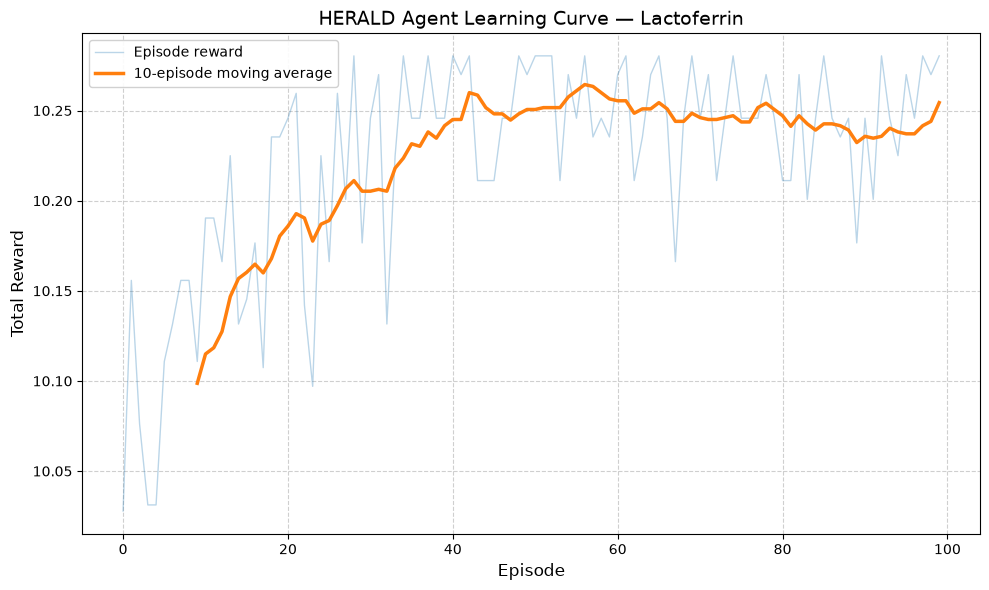

In [18]:
smoothed = np.convolve(
    results["episode_rewards"], np.ones(10) / 10, mode='valid'
)

plt.figure(figsize=(10, 6))
plt.plot(
    results["episode_rewards"],
    color='tab:blue',
    alpha=0.3,
    linewidth=1,
    label='Episode reward',
)
plt.plot(
    range(9, len(results["episode_rewards"])),
    smoothed,
    color='tab:orange',
    linewidth=2.5,
    label='10-episode moving average',
)
plt.title('HERALD Agent Learning Curve — Lactoferrin', fontsize=14)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
print(f"Best enzyme combination: {results['best_combination']}")
print(f"Estimated reward: {results['action_values'][results['best_action']]:.3f}")
print()
print("All action values:")
for i, (combo, value) in enumerate(
    zip(env.action_space, results["action_values"])
):
    marker = " ← best" if i == results["best_action"] else ""
    print(f"  {combo}: {value:.3f}{marker}")

Best enzyme combination: ['trypsin']
Estimated reward: 0.857

All action values:
  ['trypsin']: 0.857 ← best
  ['chymotrypsin']: 0.846
  ['trypsin', 'chymotrypsin']: 0.822
  ['chymotrypsin', 'trypsin']: 0.822


In [27]:
peptides = digest_sequential(
    sequence, results["best_combination"], min_length=4, max_length=50
)

probabilities = [
    predict_amp(peptide, model, alphabet, clf)[1]
    for peptide in peptides
]

candidates_df = pd.DataFrame({
    "sequence": peptides,
    "probability": probabilities,
})

candidates_df = candidates_df.sort_values(
    by="probability", ascending=False
).reset_index(drop=True)

candidates_df.head(10)

,sequence,probability
0,LFVPALLSLGALGLCLAAPR,0.999670
1,DSALGFLR,0.988959
2,QVLLHQQALFGK,0.975890
3,LRPVAAEIYGTK,0.966890
4,LGAPSITCVR,0.944859
5,ADAVTLDGGMVFEAGR,0.926269
6,CGLVPVLAENR,0.922978
7,GEADALNLDGGYIYTAGK,0.920993
8,LLSK,0.914703
9,SCHTGLGR,0.909778


In [28]:
output_path = os.path.join(PROCESSED_DIR, "rl_candidates.csv")
candidates_df.to_csv(output_path, index=False)
print(f"Saved results to: {output_path}")

Saved results to: /Users/lukas/Developer/herald/data/processed/rl_candidates.csv
